# Chapter 7 — Linear Regression Primer

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion.

Six chapters used regression-flavored ideas without ever doing a regression. Ch3 had β̂ in scatter plots. Ch4 used "regress on X" as an expected-return flavor. Ch5 had SE-of-mean. Ch6 had Σ⁻¹ — the same matrix shape as the closed-form OLS solution. Chapter 7 collects all of it into the one inferential tool the rest of the curriculum cannot live without.

The chapter has **one running example** — XLK regressed on SPY — and **three jobs you can do with a regression**: describe the relationship, decide whether it's statistically real, and use it to predict.

## What we mean by "doing a regression"

A regression has *three jobs*. Each answers a different question, uses a different statistic, and has a different failure mode:

| Flavor | Question it answers | Key statistic | Section |
|---|---|---|---|
| **Description** | What is the average relationship between *x* and *y* in this data? | β̂ (slope), α̂ (intercept), R² | §2 |
| **Inference** | Is the relationship statistically distinguishable from zero? | SE(β̂), t-stat, p-value, 95% CI | §3 |
| **Prediction** | What value of *y* should I expect for a new *x*, with what uncertainty? | ŷ, prediction interval | §4 |

The flavors are mostly additive — inference uses the descriptive fit, prediction uses both. But knowing which job you're doing tells you which error bar to trust and which pitfall to guard against.

## 1. Setup

Same library stack as Ch6 plus **`statsmodels`** — Python's standard library for regression with full inference output. Same 8-ticker basket as Ch3-6 (running example uses SPY + XLK; TLT joins in §6/§7). Daily log returns over the same 20-year window.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
from scipy import stats

print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"yfinance     {yf.__version__}")
import statsmodels
print(f"statsmodels  {statsmodels.__version__}")

numpy        2.4.4
pandas       3.0.2
yfinance     1.3.0
statsmodels  0.14.6


In [2]:
tickers = ["SPY", "XLK", "TLT", "GLD", "XLF", "XLE", "XLV", "XLU"]
prices = yf.download(tickers, period="20y", auto_adjust=True, progress=False)["Close"][tickers].dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

n_obs = len(log_returns)
print(f"shape: {log_returns.shape}")
print(f"date range: {log_returns.index.min().date()} to {log_returns.index.max().date()}")
print(f"observations: {n_obs:,}")

shape: (5030, 8)
date range: 2006-05-08 to 2026-05-05
observations: 5,030


## 2. OLS by example — description

Pick the two assets the chapter follows: **SPY** (broad market) on the x-axis, **XLK** (tech sector) on the y-axis. Both daily log returns. Roughly 5,000 days of paired observations.

The regression line answers: *on a day SPY is up 1%, what does XLK do on average?* The slope β̂ is the answer.

### 2.1 Least squares — the math in one screen

Pick (α, β) to minimise the sum of squared residuals:

> SS(α, β) = Σ<sub>t</sub> (y<sub>t</sub> − α − β·x<sub>t</sub>)²

where:
- *y<sub>t</sub>* — XLK's log return on day *t*. **Units:** decimal log return.
- *x<sub>t</sub>* — SPY's log return on day *t*. Same units.
- *α* (intercept) — average y when x = 0. Same units as y.
- *β* (slope) — change in y per unit change in x. Dimensionless ratio.

Setting the partial derivatives to zero gives the closed-form:

> β̂ = Cov(x, y) / Var(x)
>
> α̂ = ȳ − β̂·x̄

The **residual** is what's left after the fit:

> ε<sub>t</sub> = y<sub>t</sub> − α̂ − β̂·x<sub>t</sub>

The **fitted value** is what the line predicts:

> ŷ<sub>t</sub> = α̂ + β̂·x<sub>t</sub>

In [ ]:
y = log_returns["XLK"].values
X = sm.add_constant(log_returns["SPY"].values)  # adds the intercept column
fit = sm.OLS(y, X).fit()

print(fit.summary())
# The coefficients block (const, x1) is the meat - that's the focus of §3.
print()
print(f"beta(SPY)         = {fit.params[1]:.4f}")
print(f"alpha (daily)     = {fit.params[0]:.6f}")
print(f"alpha (ann., x252)= {fit.params[0] * 252:.4f}")
print(f"R^2               = {fit.rsquared:.4f}")

### Reading the summary block

Skip the coefficients block for now — that's §3. The header block carries six numbers worth knowing right now:

- **R-squared** — fraction of XLK's variance explained by SPY. About 0.84 here.
- **Adj. R-squared** — same number penalised for added regressors; matters when we add TLT in §7.
- **F-statistic, Prob (F-statistic)** — joint test that *all* slopes are zero. With one regressor it's redundant with the t-test on β; useful in §7.
- **Log-Likelihood, AIC, BIC** — model-comparison numbers; ignore until you're picking between models.

The footer block (Durbin-Watson, Jarque-Bera, Omnibus, Skew, Kurtosis, Cond. No.) is a quick assumption-audit — the same diagnostics §5 plots, in scalar form. Two-line gloss:

- **Durbin-Watson** ≈ 2.0 means no lag-1 residual autocorrelation; ours is 2.10.
- **Jarque-Bera (JB)** — joint test of skew + excess kurtosis vs Normal; big = non-Normal residuals (ours: 3,514, p ≈ 0).
- **Omnibus** — another Normality test on residuals; same flavor as JB.
- **Skew** of residuals; Normal = 0; ours = −0.14, mildly left-skewed.
- **Kurtosis** of residuals; Normal = 3; ours = 7.1, fat tails.
- **Cond. No.** — design-matrix condition number; flags multicollinearity when >30 with multiple regressors. Ours: 81.6 (single regressor, harmless).

The coefficients block is the meat of §3.

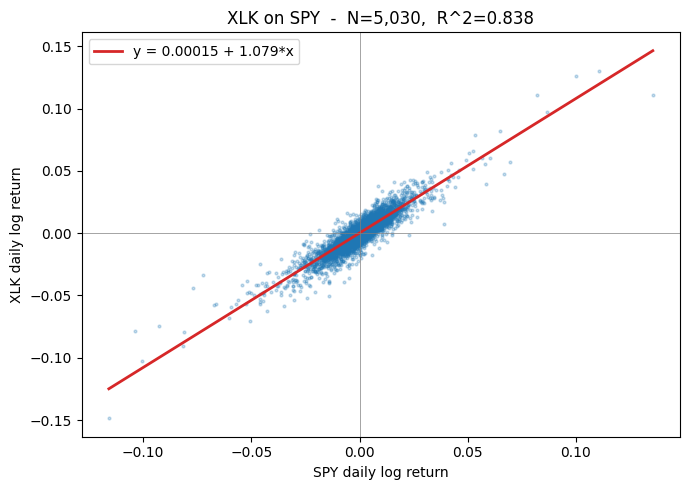

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(log_returns["SPY"], log_returns["XLK"], s=4, alpha=0.25)

xs = np.linspace(log_returns["SPY"].min(), log_returns["SPY"].max(), 200)
ys = fit.params[0] + fit.params[1] * xs
ax.plot(xs, ys, color="C3", lw=2, label=f"y = {fit.params[0]:.5f} + {fit.params[1]:.3f}*x")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("SPY daily log return")
ax.set_ylabel("XLK daily log return")
ax.set_title(f"XLK on SPY  -  N={n_obs:,},  R^2={fit.rsquared:.3f}")
ax.legend()
fig.tight_layout()
plt.show()

**Reading the picture.** β̂ ≈ 1.08 means: *on a day SPY is up 1%, XLK is up about 1.08% on average.* α̂ ≈ +0.00015 daily (≈ 3.7% annualized at 252 trading days) means: *controlling for SPY, XLK has a small positive average daily drift.* R² ≈ 0.84 means: *about 84% of XLK's daily-return variance is explained by SPY's.*

**Look at the points furthest from the line — those are 2008-09 (Lehman / GFC), March 2020 (COVID), and 2022 (rate-shock selloff) days.** Those are the days SPY's slope misses XLK's move by the most; they're also the days where the cloud visibly widens. §5 confirms that widening as heteroskedasticity + fat tails.

Three caveats sit immediately under this picture:
1. β̂ is an *average* — individual days vary, sometimes a lot. That dispersion is the residual.
2. R² ≈ 0.84 is high *for a regression of one asset on another*. It's not high in absolute terms — about a sixth of XLK's variance is *not* SPY-explained, and that sixth is exactly where stockpicking lives.
3. The annualized α of 3.7% sounds meaningful — but is it *statistically* distinguishable from zero? §3 quantifies the error bars.

## 3. Inference — is the relationship real?

§2 said β̂ ≈ 1.08 and annualized α̂ ≈ 3.7%. Inference asks: *are those numbers statistically distinguishable from zero?* The answer rides on the standard errors.

### 3.1 Standard error, t-statistic, confidence interval

Same machinery as Ch5's SE-of-mean, applied to a slope:

> SE(β̂) = σ̂<sub>ε</sub> / √(Σ (x<sub>t</sub> − x̄)²)

where:
- *σ̂<sub>ε</sub>* — sample standard deviation of the residuals. **Units:** decimal log return.
- *x<sub>t</sub>*, *x̄* — SPY's daily log return at *t* and its sample mean. Same units.
- *SE(β̂)* — the standard error of the slope. Dimensionless (slope of decimals on decimals).

The shape mirrors SE(μ̂) = σ/√N: more data and more spread in *x* both make the slope estimate more precise.

The **t-statistic** under H₀: β = β₀ is:

> t = (β̂ − β₀) / SE(β̂)

For large N (we have ≈5,000), t is approximately standard normal. The **95% confidence interval** is β̂ ± 1.96·SE(β̂). The **p-value** is the probability of seeing |t| this large or larger under H₀.

In [5]:
coef_table = pd.DataFrame({
    "coef":    fit.params,
    "std err": fit.bse,
    "t":       fit.tvalues,
    "P>|t|":   fit.pvalues,
    "[0.025":  fit.conf_int()[:, 0],
    "0.975]":  fit.conf_int()[:, 1],
}, index=["alpha", "beta(SPY)"])
print(coef_table.round(6))

               coef   std err           t     P>|t|    [0.025    0.975]
alpha      0.000148  0.000082    1.798330  0.072185 -0.000013  0.000309
beta(SPY)  1.079463  0.006697  161.191918  0.000000  1.066334  1.092591


### 3.2 Reading the coefficients block, line by line

For each coefficient row:

- **coef** — the point estimate. β̂ ≈ 1.08; α̂ ≈ +0.000147 daily.
- **std err** — SE(β̂). Tiny here because N is large and SPY's daily-return spread is wide.
- **t** — point estimate divided by its standard error. **161 for β** (overwhelming); **1.80 for α** (borderline).
- **P>|t|** — the p-value for H₀: coefficient = 0. ~0 for β; **0.073 for α** — does *not* reject at 95%.
- **[0.025, 0.975]** — the 95% confidence interval. Excludes zero by a country mile for β; **straddles zero for α** ((−0.0034, +0.0777) annualized — almost includes zero).

In [6]:
alpha_daily = fit.params[0]
alpha_ann   = alpha_daily * 252
ci_daily    = fit.conf_int()[0]
ci_ann      = ci_daily * 252

print(f"alpha (daily):       {alpha_daily:+.6f}")
print(f"alpha (annualized):  {alpha_ann:+.4f}")
print(f"95% CI (annualized): ({ci_ann[0]:+.4f}, {ci_ann[1]:+.4f})")
print(f"t(alpha):            {fit.tvalues[0]:+.3f}")
print(f"p(alpha):            {fit.pvalues[0]:.3f}")

alpha (daily):       +0.000148
alpha (annualized):  +0.0372
95% CI (annualized): (-0.0034, +0.0777)
t(alpha):            +1.798
p(alpha):            0.072


### 3.3 Two natural tests

**Is β = 0?** No — t ≈ 161, p ≈ 0. XLK's daily return is overwhelmingly explained by SPY's. *Boring* — anyone watching tech and the broad market knows this.

**Is α = 0?** This is the *interesting* test. Annualized α̂ ≈ 3.7% with 95% CI (−0.3%, +7.8%) and t ≈ 1.80, p ≈ 0.07. **The CI just barely includes zero** — XLK's apparent outperformance is *not* statistically distinguishable from zero at the conventional 95% level, even with 20 years of data. *With another 2-3 years of similar daily data — assuming α̂ stays near +0.000148 — the SE shrinks enough that the lower CI bound crosses zero.*

This is the sceptical foundation for Ch8's CAPM-α discussion: even on assets that *look* like they outperformed, with two decades of evidence, the statistical case is borderline.

> **Foot-gun: the textbook SEs assume i.i.d. Gaussian residuals.** *i.i.d. = independent and identically distributed — every observation drawn the same way, with no carryover from past values.* Daily-equity residuals are neither (vol clustering — Ch2; fat tails — Ch2 and Ch10). The textbook p-values are therefore *slightly* optimistic; true confidence intervals are *slightly* wider. §5 exposes the violations diagnostically; full robust treatment uses **HAC / Newey-West** SEs (`cov_type='HAC'` in statsmodels) — *HAC = heteroskedasticity-and-autocorrelation-consistent SEs; corrects exactly the §5 violations.* Named only here.

## 4. Prediction and R²

§4 separates two things readers often conflate: **R²** (an *in-sample* descriptive statistic) and **prediction** (claiming the line will hold on new data, with its own error bar).

### 4.1 R² formally

> R² = 1 − SS<sub>res</sub> / SS<sub>tot</sub>

where:
- *SS<sub>res</sub>* = Σ (y<sub>t</sub> − ŷ<sub>t</sub>)² — residual sum of squares.
- *SS<sub>tot</sub>* = Σ (y<sub>t</sub> − ȳ)² — total sum of squares.
- *R²* — the in-sample fraction of variance explained. Range [0, 1] (assuming intercept). In simple regression, equals the squared Pearson correlation.

**Adjusted R²** penalises for added regressors:

> R²<sub>adj</sub> = 1 − (1 − R²) · (n − 1) / (n − k − 1)

where *k* is the number of regressors (excluding the constant). When k = 1, adjusted and raw R² are nearly identical; the gap matters in §7.

In [7]:
y_bar = y.mean()
ss_tot = ((y - y_bar) ** 2).sum()
ss_res = (fit.resid ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"SS_tot   = {ss_tot:.4f}")
print(f"SS_res   = {ss_res:.4f}")
print(f"R^2      = {r2:.6f}")
print(f"summary() R^2 = {fit.rsquared:.6f}  (matches by hand)")

SS_tot   = 1.0498
SS_res   = 0.1702
R^2      = 0.837863
summary() R^2 = 0.837863  (matches by hand)


### 4.2 What R² is *not*

R² is the **in-sample** fraction of variance explained by the fit on *this* data. It is *not* the fraction the model will explain on new data. Out-of-sample R² is typically lower; on poor models, can go negative (worse than predicting the mean).

A model can have R² = 0.95 on its training data and R² = 0 (or negative) on next month's data. R² alone tells you nothing about predictive ability. **Out-of-sample testing is Chapter 13.**

In [8]:
x_new = 0.01  # a +1% SPY day
y_hat = fit.params[0] + fit.params[1] * x_new

predict_obj = fit.get_prediction(np.array([[1.0, x_new]]))
ci = predict_obj.conf_int(alpha=0.05)[0]              # CI on the regression line
pi = predict_obj.conf_int(obs=True, alpha=0.05)[0]    # prediction interval (line + scatter)

print(f"x_new = {x_new:+.4f}  (a +1% SPY day)")
print(f"predicted XLK return: {y_hat:+.4f}")
print(f"95% CI on the line:    ({ci[0]:+.4f}, {ci[1]:+.4f})  width = {ci[1]-ci[0]:.4f}")
print(f"95% prediction interval: ({pi[0]:+.4f}, {pi[1]:+.4f})  width = {pi[1]-pi[0]:.4f}")

x_new = +0.0100  (a +1% SPY day)
predicted XLK return: +0.0109
95% CI on the line:    (+0.0107, +0.0111)  width = 0.0004
95% prediction interval: (-0.0005, +0.0224)  width = 0.0228


**Two error bars, two questions.** The narrow interval — the **CI on the regression line** — answers *how confident am I about where the line actually is?* The wide interval — the **prediction interval** — answers *how confident am I about a single new XLK return on a day SPY moves +1%?* The second is much wider because it includes the irreducible day-to-day scatter (the residual variance) on top of line-fitting uncertainty.

Forward pointer: every number in this chapter is in-sample. Out-of-sample testing — *do these intervals actually cover their nominal 95% on data the model hasn't seen?* — is Ch13.

## 5. Residual diagnostics — three plots that audit the SEs

§3's standard errors assume residuals are independent and normally distributed. Three plots check whether that assumption holds; each one has a name and a fix when it doesn't.

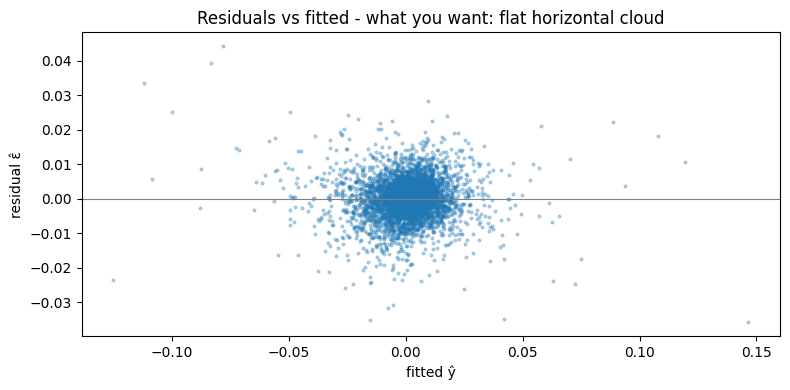

In [9]:
resid = fit.resid
fitted = fit.fittedvalues

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(fitted, resid, s=4, alpha=0.3)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("fitted ŷ")
ax.set_ylabel("residual ε̂")
ax.set_title("Residuals vs fitted - what you want: flat horizontal cloud")
fig.tight_layout()
plt.show()

**What you want:** flat horizontal cloud around zero, constant width. **Three pathologies:**

- *Curvature* — the relationship isn't linear after all (e.g., the cloud bends).
- *Fan shape* (heteroskedasticity) — residual variance grows with x; SEs are wrong.
- *Clusters* — an omitted nonlinear effect or regime structure.

Daily SPY/XLK residuals are roughly flat-cloud, but with a noticeable widening near the extremes — the fat-tail signature.

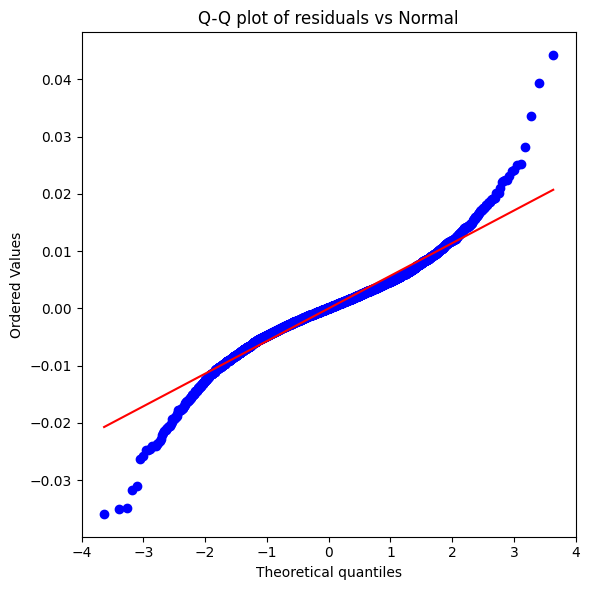

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(resid, dist="norm", plot=ax)
ax.set_title("Q-Q plot of residuals vs Normal")
fig.tight_layout()
plt.show()

**What you want:** the points sit on the diagonal. **Pathology:** the points peel away at the ends — the residual distribution has fatter tails than the Normal it's being compared to.

Daily-equity residuals *will* show fat-tail departure; this is Ch2's lesson restated. The kurtosis of these residuals (≈7.1, vs Normal's 3.0) is exactly the same fat-tail finding from Ch2 §1, transferred to the regression scale. Textbook p-values are therefore *slightly* optimistic; true CIs are *slightly* wider. The proper fix is **Extreme Value Theory** on residuals — Ch10. For now: report the p-values, but don't treat a t = 2.05 like a discovery.

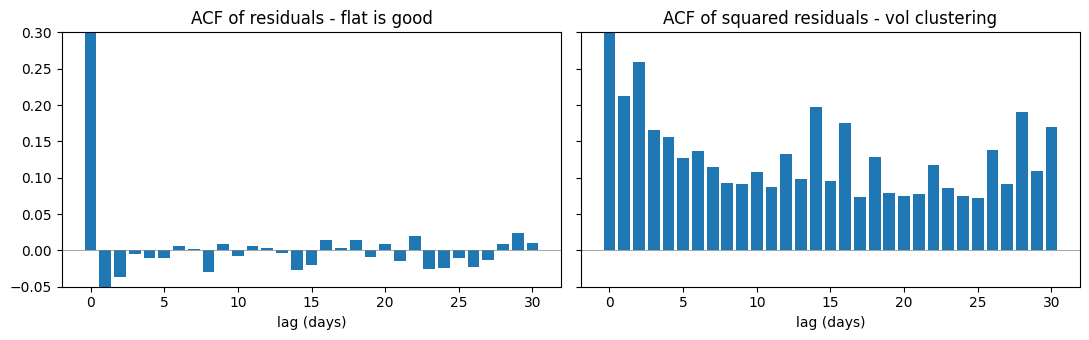

In [11]:
lags = 30
acf_r  = acf(resid,       nlags=lags, fft=True)
acf_r2 = acf(resid ** 2,  nlags=lags, fft=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
axes[0].bar(range(lags + 1), acf_r);  axes[0].axhline(0, color="gray", lw=0.5)
axes[0].set_title("ACF of residuals - flat is good")
axes[1].bar(range(lags + 1), acf_r2); axes[1].axhline(0, color="gray", lw=0.5)
axes[1].set_title("ACF of squared residuals - vol clustering")
for a in axes: a.set_xlabel("lag (days)"); a.set_ylim(-0.05, 0.30)
fig.tight_layout()
plt.show()

**Residual ACF (left)** is flat near zero — the i.i.d. assumption mostly survives at the level of residuals themselves (mild lag-1 negative ACF of −0.05, consistent with daily noise; nothing structural). **Squared-residual ACF (right)** is *not* flat — values around 0.20-0.26 at the first few lags, slow decay across many more. That is **vol clustering** showing up cleanly: today's |residual| predicts tomorrow's |residual|.

This is the Ch9 GARCH preview. The fix for time-correlated residual *variance* is GARCH; the fix for any time-correlated residuals at the *level* is HAC SEs (`cov_type='HAC'`, named only here).

## 6. Pitfalls — the three ways regression fools you

Three classic failure modes. Each gets one paragraph and one numerical illustration.

In [12]:
X_single = sm.add_constant(log_returns["SPY"].values)
X_multi  = sm.add_constant(log_returns[["SPY", "TLT"]].values)
fit_single = sm.OLS(y, X_single).fit()
fit_multi  = sm.OLS(y, X_multi).fit()

print(f"single (XLK on SPY only):    beta(SPY) = {fit_single.params[1]:.5f}")
print(f"multi  (XLK on SPY + TLT):   beta(SPY) = {fit_multi.params[1]:.5f},  beta(TLT) = {fit_multi.params[2]:.5f}")
print(f"OVB on SPY beta:             {fit_single.params[1] - fit_multi.params[1]:+.5f}")

single (XLK on SPY only):    beta(SPY) = 1.07946
multi  (XLK on SPY + TLT):   beta(SPY) = 1.09184,  beta(TLT) = 0.05220
OVB on SPY beta:             -0.01237


### 6.1 Omitted-variable bias (OVB)

When a regression leaves out a variable that (a) explains *y* and (b) correlates with the included regressor, the included coefficient absorbs some of the omitted variable's effect. Adding TLT to the regression shifts SPY's coefficient by about −0.012 — small, because SPY and TLT are weakly correlated over this window. **TLT's own coefficient (+0.052, t > 5) is small but statistically distinguishable** — XLK has a real, mild positive bond loading that the SPY-only regression hid inside ε.

<details><summary>Closed-form OVB</summary>

If the true model is y = α + β₁·x₁ + β₂·x₂ + ε but you fit y = α + γ·x₁ + ν, then E[γ̂] = β₁ + β₂ · Cov(x₁, x₂)/Var(x₁). The bias is the slope of x₂ on x₁ times the omitted coefficient.

</details>

The §7 multi-regression is the same fit, repurposed: same data, same software, more regressors.

### 6.2 Look-ahead bias

Regressing today's return on tomorrow's information looks predictive — and isn't. Easy to introduce accidentally: rolling z-scores computed with future data, target-leakage in feature engineering, label-aligned-wrong rolling joins.

The fix is procedural: every feature available at time *t* must be available *strictly before t*. Concept revisited rigorously in Ch13 backtesting.

In [13]:
rng = np.random.default_rng(20260505)
N_STEPS = 5_000
rw1 = rng.standard_normal(N_STEPS).cumsum()
rw2 = rng.standard_normal(N_STEPS).cumsum()
fit_spurious = sm.OLS(rw2, sm.add_constant(rw1)).fit()
print(f"two independent random walks, N={N_STEPS}:")
print(f"  beta = {fit_spurious.params[1]:+.4f}")
print(f"  t    = {fit_spurious.tvalues[1]:+.2f}")
print(f"  R^2  = {fit_spurious.rsquared:.3f}")

two independent random walks, N=5000:
  beta = +0.1094
  t    = +5.26
  R^2  = 0.006


### 6.3 Spurious correlation

Two random walks with no causal connection can produce a regression with massive |t| (and on different seeds, sometimes also impressive R²). The numbers look real because the walks share *trend*, not because either drives the other. This is the **spurious-regression** problem.

The empirical fix is to regress on *changes* (returns), not *levels* (prices). When the levels really do co-move, the proper response is **cointegration** analysis (named only here). **Exercise 4** makes the point quantitatively: across 100 trials of independent random walks of length 5,000, the conventional |t| > 2 bar is cleared in roughly 90+% of cases.

## 7. Multiple regression briefly

Two regressors instead of one. The math is exactly Ch6's Σ⁻¹ shape.

### 7.1 The math

> y = α + β₁·x₁ + β₂·x₂ + ε

In matrix form: y = Xβ + ε with X = [1 | x₁ | x₂]. The closed form is:

> β̂ = (XᵀX)⁻¹ Xᵀ y

where:
- *X* — n × (k + 1) design matrix; first column all 1s for the intercept; remaining k columns the regressors.
- *β̂* — (k + 1) × 1 column of estimated coefficients (intercept first).
- *(XᵀX)⁻¹* — same matrix-inverse shape as Ch6's Σ⁻¹. Same instability when columns of X are highly correlated.

That instability is **multicollinearity** — when two regressors carry nearly the same information, their individual coefficients become unstable (huge SEs) even though the overall fit is fine. One-paragraph gloss only; named extensions (variance inflation factors, partial regression plots) are out of scope.

In [14]:
fit_multi = sm.OLS(y, X_multi).fit()
print(fit_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                 1.309e+04
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        11:33:24   Log-Likelihood:                 18768.
No. Observations:                5030   AIC:                        -3.753e+04
Df Residuals:                    5027   BIC:                        -3.751e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001   8.19e-05      1.659      0.0

**Reading the multi-regression.** SPY's coefficient barely moves from §2 (small OVB; SPY/TLT have low correlation over this window). TLT's coefficient is +0.052 with t ≈ 5.7 — small but statistically distinguishable. R² ticks up from 0.838 to 0.839.

**The hidden lesson:** TLT carries *additional* information about XLK's daily moves beyond what SPY captures, but only a tiny amount. The "right" answer to the question *what determines XLK's daily return* requires more than just SPY — but adding regressors hits diminishing returns fast. Ch8 will name the more useful additions: SMB and HML factors.

## 8. Recap by flavor

- **Description** (β̂, α̂, R²) — the average relationship in this data. Easy to compute, easy to over-interpret.
- **Inference** (SE, t, CI, p) — is the relationship statistically distinguishable from zero? Critical in finance: most things look related at the point estimate; few survive a CI audit. (XLK's apparent 3.7% annualized α has p = 0.073 — borderline.)
- **Prediction** (ŷ, prediction interval) — what to expect for a new x, with much wider error bars than the line CI.
- **Diagnostics** (residuals vs fitted, Q-Q, ACF) — three plots that tell you whether the SEs you just trusted should actually be trusted.
- **Pitfalls** (OVB, look-ahead, spurious) — avoid these and a regression is a tool; ignore them and a regression is how to fool yourself with statistics.

## 9. So what?

**Decision rules:**

- **Always look at the residual plots** before trusting the SEs. A regression you haven't diagnosed is a regression you don't trust.
- **t > 2 is the conventional bar.** But finance tests many things; a single t = 2.1 in a 5,000-sample fit is p ≈ 0.04, well within the tested-many-things zone.
- **R² is not a quality score.** R² = 0.84 between XLK and SPY says they move together, not that the fit is "good." Out-of-sample is Ch13.
- **Add a regressor when you suspect OVB; remove when collinearity blows up SEs.** §7's TLT addition is the OVB-add example.

**What this chapter can't yet tell you:**

- Whether the relationship is *causal*. OLS is correlational. Causal identification (instrumental variables, RDD, DID) is out of scope.
- Whether the relationship survives out of sample. **Ch13.**
- How to combine many correlated regressors with shrinkage (ridge, lasso). Out of scope; **Ch8** Fama-French is the closest in-scope case.
- How to handle classification problems. **Future Ch12.**

## Key Terms

| Term | Definition |
|---|---|
| Ordinary least squares (OLS) | The procedure that picks (α, β) to minimise the sum of squared residuals. |
| Residual | Observed minus fitted value, ε̂<sub>t</sub> = y<sub>t</sub> − ŷ<sub>t</sub>. |
| Fitted value | The model's prediction at an observed x, ŷ<sub>t</sub> = α̂ + β̂·x<sub>t</sub>. |
| Slope (β̂) | Change in y per unit change in x, on average. |
| Intercept (α̂) | Average y when x = 0. |
| Standard error of a coefficient | The standard deviation of the coefficient's sampling distribution. |
| t-statistic | (Coefficient − null value) / SE. Approximately standard-normal under H₀ for large N. |
| p-value | Probability of seeing \|t\| this large or larger under H₀. |
| 95% confidence interval | β̂ ± 1.96·SE(β̂). The range of slope values consistent with the data at 95%. |
| R² (coefficient of determination) | In-sample fraction of variance in y explained by the regression. |
| Adjusted R² | R² penalised for added regressors. |
| Prediction interval | Error bar on a new ŷ, wider than the CI on the regression line because it includes residual scatter. |
| Heteroskedasticity | Residual variance that depends on x. Breaks textbook SE formulas. |
| Autocorrelated residuals | Residuals where ε̂<sub>t</sub> predicts ε̂<sub>t+1</sub>. Breaks the i.i.d. SE assumption. |
| Omitted-variable bias (OVB) | Bias in an included coefficient from leaving out a correlated regressor that also explains y. |
| Multicollinearity | Two regressors carrying near-identical information; produces unstable individual coefficients. |
| Look-ahead bias | Using future information to predict the present. Inflates apparent fit. |
| Spurious correlation | Apparent regression relationship between unrelated series, often via shared trend. |
| `statsmodels` (named) | Python library providing OLS with full inference output (SEs, t-stats, p-values, CIs). |

## Exercises

Try these in fresh cells below. Solutions are not provided — the goal is to consolidate the chapter's machinery on slightly different inputs.

1. **Per-asset CAPM-style table.** For each of TLT, GLD, XLF, XLE, XLV, XLU, regress its daily log return on SPY's. Tabulate β̂, α̂ (annualized), t(α̂), t(β̂), R². Which sectors have R² above 0.80? Which have α̂ statistically distinguishable from zero at 95%?

2. **OVB illustration.** Regress XLE on SPY only, then on SPY + GLD. How much does XLE's SPY coefficient change? What does the SPY-only regression's residual contain that the multi-regressor fit pulls out into a separate β?

3. **Diagnose a residual.** Take any single-regressor fit from Exercise 1 and plot the three diagnostic plots from §5 (residuals vs fitted, Q-Q vs Normal, ACF of squared residuals). Which pathologies (fat tails, autocorrelation, heteroskedasticity) appear?

4. *(stretch)* **Spurious-correlation drill.** Generate two independent random walks of length N = 5,000. Regress one on the other. What R² do you get? What t-statistic on the slope? Repeat 100 times and plot the distribution of |t|. How often does |t| > 2 by pure chance?


End of notebook. Read the chapter [`README.md`](./README.md) for the canonical narrative.